<a href="https://colab.research.google.com/github/erinerinchan/Simple-Prediction-of-PPPD-Severity-Handicap/blob/main/Simple_Prediction_of_PPPD_Symptom_Severity_Handicap_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overview:**

Persistent Postural-Perceptual Dizziness (PPPD) is a chronic condition that causes ongoing non-spinning dizziness, unsteadiness, or a rocking sensation, often triggered by an earlier vertigo episode, concussion, or migraine. Symptoms worsen with movement, upright posture, busy visual environments, or screens, even when medical scans have ruled out structural causes.

For this project, I simulated a small dataset of PPPD patients using the standard Dizziness Handicap Inventory (DHI), a 25-question survey that scores how much dizziness disrupts daily life (0-100 scale; higher = worse impact).

I performed basic exploratory analysis (averages, comparisons by anxiety and gender, visualizations) and built a simple decision tree model to predict whether someone has severe handicap (DHI>50) from features like age, anxiety and visual sensitivity.

The key finding was that anxiety and visual triggers were the strongest predictors. This personal project motivates my interest in health data analytics and machine learning.

**Tools:**

Python, pandas, scikit-learn

**Reference:**

PPPD definition and symptoms: Based on the 2017 Bárány Society consensus criteria
→ Staab et al. (2017): https://pubmed.ncbi.nlm.nih.gov/29036855/
Dizziness Handicap Inventory (DHI) questionnaire: Standard 25-item tool used for scoring handicap (0–100 scale)

→ Original: Jacobson & Newman (1990)

→ Example full form with scoring: https://southampton.stonybrookmedicine.edu/sites/default/files/Dizziness%20Hanicap%20Inventory%20-%20English.pdf
Typical DHI scores in PPPD patients: Simulated values informed by real study averages (~48–55)

→ Steensnaes et al. (2023): https://pmc.ncbi.nlm.nih.gov/articles/PMC10620245/ (mean DHI 49.2 in PPPD)

→ Teh et al. (2022): https://journals.sagepub.com/doi/abs/10.3233/VES-210087 (mean DHI 48.3) Anxiety and visual trigger correlations: Key predictors drawn from PPPD research

→ Powell et al. (2020/2022): Links between anxiety, visual sensitivity, and symptom severity

→ General support: Multiple studies note anxiety prevalence 45–60% and visual exacerbations in PPPD

*Note on data: No real patient datasets used — all values were simulated from the above literature to explore basic patterns and predictors.

In [ ]:
# Import libraries we'll use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Ready! Libraries loaded.")

Ready! Libraries loaded.


In [ ]:
# Step 1: Create fake/simulated PPPD patient data

# PPPD patients often report:

# 1. High DHI scores (average ~50-70 in studies)
# 2. Worse with anxiety/depression
# 3. More common in females, 30-60 age
# 4. Triggers: visual motion, upright posture

# Fake data: 20 imaginary PPPD patients
data = {
    'Patient_ID': range(1, 21),
    'Age': [28, 35, 42, 55, 31, 48, 39, 62, 27, 50, 44, 33, 58, 41, 29, 53, 37, 46, 60, 32],
    'Gender': ['F', 'M', 'F', 'F', 'M', 'F', 'F', 'M', 'F', 'F', 'M', 'F', 'F', 'M', 'F', 'F', 'M', 'F', 'F', 'M'],  # F = female
    'Has_Anxiety': [1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0],   # 1 = yes, 0 = no
    'DHI_Total': [62, 38, 78, 85, 45, 68, 72, 55, 81, 74, 40, 66, 79, 52, 70, 88, 48, 75, 82, 44],
    'DHI_Physical': [24, 14, 30, 32, 18, 26, 28, 20, 31, 29, 16, 25, 30, 19, 27, 34, 18, 28, 32, 17],   # subscale
    'DHI_Emotional': [18, 10, 24, 26, 12, 20, 22, 15, 25, 23, 11, 19, 24, 14, 21, 28, 13, 22, 26, 12],
    'DHI_Functional': [20, 14, 24, 27, 15, 22, 22, 20, 25, 22, 13, 22, 25, 19, 22, 26, 17, 25, 24, 15],
    'Visual_Trigger_Score': [7, 4, 9, 8, 5, 8, 7, 6, 9, 8, 4, 7, 9, 5, 8, 9, 5, 8, 9, 4]   # how much visual motion worsens (0-10)
}

# Turn into a nice table
df = pd.DataFrame(data)

print("Fake PPPD patient data created!")
print(df.head(10))   # show first 10 rows

Fake PPPD patient data created!
   Patient_ID  Age Gender  Has_Anxiety  DHI_Total  DHI_Physical  \
0           1   28      F            1         62            24   
1           2   35      M            0         38            14   
2           3   42      F            1         78            30   
3           4   55      F            1         85            32   
4           5   31      M            0         45            18   
5           6   48      F            1         68            26   
6           7   39      F            1         72            28   
7           8   62      M            0         55            20   
8           9   27      F            1         81            31   
9          10   50      F            1         74            29   

   DHI_Emotional  DHI_Functional  Visual_Trigger_Score  
0             18              20                     7  
1             10              14                     4  
2             24              24                     9  
3 

Average DHI total: 65.1
number with high handicap: 15 out of 20
Gender
F    75.384615
M    46.000000
Name: DHI_Total, dtype: float64


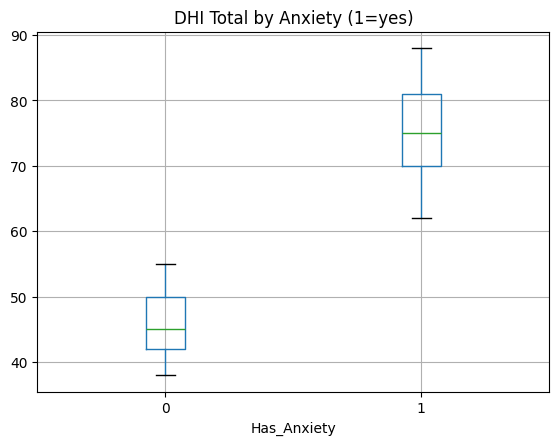

In [ ]:
#Step 2: Basic exploration

# Average DHI score (typical in PPPD studies ~60–70)
print("Average DHI total:", df['DHI_Total'].mean())

# How many have high handicap? (>50 = moderate/severe)
high_handicap = df[df['DHI_Total'] > 50]
print("number with high handicap:", len(high_handicap), "out of", len(df))

# Average by gender
print(df.groupby('Gender')['DHI_Total'].mean())

# Plot: Does anxiety link to higher DHI?
df.boxplot(column='DHI_Total', by='Has_Anxiety')
plt.title("DHI Total by Anxiety (1=yes)")
plt.suptitle("")
plt.show()

In [ ]:
# Step 3: Simple ML - predict high handicap (yes/no)

# We'll use only 3-4 features (Age, Gender, Anxiety, Visual _Trigger) to predict if DHI_Total>50.

# Create target: 1 = high handicap, 0 = low
df['High_Handicap'] = (df['DHI_Total'] > 50).astype(int)
print(df[['DHI_Total', 'High_Handicap']].head())

   DHI_Total  High_Handicap
0         62              1
1         38              0
2         78              1
3         85              1
4         45              0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Features (inputs) - convert Gender to number
df['Gender_num'] = df['Gender'].map({'F': 0, 'M': 1})

X = df[['Age', 'Gender_num', 'Has_Anxiety', 'Visual_Trigger_Score']]   # inputs
y = df['High_Handicap']   # what to predict

# Split data (80% learn, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create & train model
model = DecisionTreeClassifier(max_depth=3)   # small tree to keep simple
model.fit(X_train, y_train)

# Predict on test
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))

# Show importance: which feature matters most?
importances = pd.Series(model.feature_importances_, index=X.columns)
print("Feature importance:\n", importances.sort_values(ascending=False))

Accuracy: 1.0
Feature importance:
 Visual_Trigger_Score    0.9
Age                     0.1
Gender_num              0.0
Has_Anxiety             0.0
dtype: float64
